Kai Gandingco (kcg2279) <br>
COE 311K <br>
Due 30 April 2026 <br>

# Final Project: Part 2

## Section 1: Introduction & System Selection
I selected Option E, which models a population undergoing rapid birth-death turnover amidst slow environmental fluctuations, thus impacting carrying capacity. This results in a stiff ordinary differential equation. The governing ordinary differential equation is <br><br>$$\frac{dN}{dt} = -\lambda\ (N - N_{carrying}(t))$$<br>where $N(t)$ represents the population size at time $t$, $\lambda$ is the rate at which the population approaches equilibrium, and $N_{carrying}(t)$ is the carrying capacity, dependent on time and available resources. Using the given parameters for stiffness, $\lambda = 10^3$ indicates extremely rapid population turnover while $N_{carrying}(t)=10^6\ (1 + 0.5\ sin(0.1t))$ reflects a slowly varying environmental influence. The initial condition $N(0) = 10^5$ then indicates that the population begins below equilibrium. Together, these conditions could reflect a rapidly fluctuating bacteria population experiencing periodic changes in resources like space or available nutrients. Understanding this, this type of model is thus important because it can provide insight into real-world systems, like the population dynamics of viruses; modeling these dynamics is crucial for predicting and combatting the spread of disease.

In [13]:
# Section 2: Demonstration of Stiffness

# Part 1: Attempt Euler's Forward

import numpy as np
import matplotlib.pyplot as plt

# Parameter definitions
lamb = 10**3 # rate at which population approaches equilibrium
N0 = 10**5 # initial condition
startTime, endTime = 0, 10

# Carrying capacity function, dependent on time
def N_carrying(t):
    return 10**6 * (1 + 0.5 * np.sin(0.1 * t)) # slow time scale will be 1/0.1

# ODE definition
def f(t, N):
    return -lamb * (N - N_carrying(t))

In [14]:
# Euler's Forward Method
def euler_forward(h):
    t = np.arange(startTime, endTime + h, h) # time intervals
    N = np.zeros(len(t))
    N[0] = N0 # initial condition
    
    for i in range(len(t)-1):
        N[i+1] = N[i] + h * f(t[i], N[i])
        # current slope estimates next point
        
    return t, N

<ipython-input-13-8769dbcde010>:19: RuntimeWarning: overflow encountered in double_scalars
  return -lamb * (N - N_carrying(t))
<ipython-input-14-eb895f0324e7>:8: RuntimeWarning: invalid value encountered in double_scalars
  N[i+1] = N[i] + h * f(t[i], N[i])


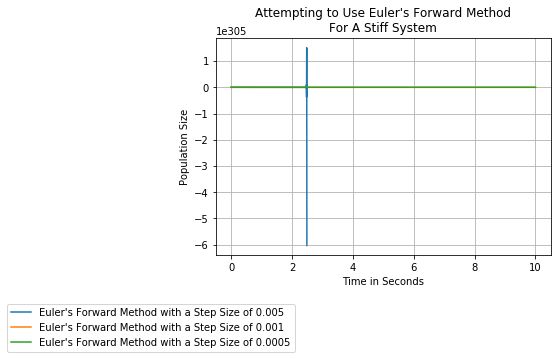

In [15]:
step_sizes = [0.005, 0.001, 0.0005]

plt.figure()

for h in step_sizes:
    t, N = euler_forward(h)
    plt.plot(t, N, label=f"Euler's Forward Method with a Step Size of {h}")
    
# Plotting
plt.title("Attempting to Use Euler's Forward Method\nFor A Stiff System")
plt.xlabel("Time in Seconds")
plt.ylabel("Population Size")
plt.legend(bbox_to_anchor = (0.25, -0.2))
plt.grid()
plt.show()

In [16]:
# Part 2: Calculate or estimate the stiffness ratio

fast_time = 1 / lamb
slow_time = 1 / 0.1
stiffness = slow_time / fast_time # Nonlinear
print(f"Estimated Stiffness Ratio: {stiffness}")

Estimated Stiffness Ratio: 10000.0


## Section 2: Demonstration of Stiffness
### Part 2: Calculate or estimate the stiffness ratio
An approximate stiffness ratio of 10,000 is very high, meaning this system is very stiff. This suggests that the system's dynamics rely on vastly different time scales, with one part of the system changing around 10,000 times faster than another.

### Part 3: Show the impracticality of explicit methods
In Section 2, Part 1, my unsuccessful attempts to plot solutions to the system are evidence of how impractical and unstable explicit methods are in regard to this model. Stability would require a step size even smaller than 0.005; specifically, the step size may have to be as small as 0.001 in order to even be plotted. This step size is extremely tiny, and using it would require 10,000 steps to span 10 seconds, which would cause wholly unnecessary computational burden. Therefore, the use of implicit methods is crucial in representing this model.

## Section 3: Mathematical Setup

For the stiff population model, the governing differential equation is

$$\frac{dN}{dt} = -\lambda \left(N - N_{carrying}(t)\right)$$

where, using the given parameters for stiffness, $N_{carrying}(t) = 10^6\ (1 + 0.5\sin(0.1t))$ and $\lambda = 10^3$. This differential equation can also be written in the linear form

$$\frac{dN}{dt} = -\lambda N + \lambda N_{carrying}(t)$$

so that 

$$f(t,N) = -\lambda N + \lambda N_{carrying}(t).$$

Using Euler's Backward Method, the model is represented as

$$N_{n+1} = N_n + h f(t_{n+1}, N_{n+1}).$$

Because $N_{n+1}$ appears on both sides, this method is implicit. To solve for $N_{n+1}$, we define the residual function as

$$g(N_{n+1}) = N_{n+1} - N_n - h f(t_{n+1}, N_{n+1}).$$

Then, we substitue the ODE to find that

$$g(N_{n+1}) = N_{n+1} - N_n - h\ [-\lambda N_{n+1} + \lambda N_{carrying}(t_{n+1})]$$

which simplifies to

$$g(N_{n+1}) = N_{n+1} - N_n + h\ \lambda N_{n+1} - h\ \lambda N_{carrying}(t_{n+1}).$$

### Derivative Setup
The derivative for Newton-Raphson is

$$g'(N_{n+1}) = 1 - h\frac{\partial f}{\partial N}.$$

Since $\frac{\partial f}{\partial N} = -\lambda$, we get $g'(N_{n+1}) = 1 - h\ (-\lambda)$ or

$$g'(N_{n+1}) = 1 + h\lambda.$$

Since this derivative is constant, it only needs to be computed once per step size. Thus, the Newton-Raphson update formula is

$$N_{n+1}^{(k+1)} = N_{n+1}^{(k)} - \frac{g(N_{n+1}^{(k)})}{g'(N_{n+1}^{(k)})}.$$

For this specific problem,

$$N_{n+1}^{(k+1)} = N_{n+1}^{(k)} - \frac{N_{n+1}^{(k)} - N_n - h\ (-\lambda N_{n+1}^{(k)} + \lambda N_{carrying}(t_{n+1}))}{1 + h\lambda}.$$

This setup allows Euler's Backward Method to remain stable for much larger step sizes than Euler's Forward Method, which is important for efficiently modeling stiff systems.

In [17]:
# Side note: formatting these markdown cells was actually the most
# frustrating step in this entire part of the project LOL </3

In [18]:
# Section 4: Implementation

# Parameter definitions for Newton-Raphson
backward_step_sizes = [0.01, 0.005, 0.001, 0.0005]
tolerance = 1e-6
max_iterations = 20

In [19]:
# Residual function
def residual(N_next, N_current, t_next, h):
    return N_next - N_current - h * f(t_next, N_next)

# Derivative function
def derivative(h):
    return 1 + h * lamb

# Newton-Raphson solver
def nr_solver(N_current, t_current, h, tolerance=1e-6, max_iterations=20):
    t_next = t_current + h
    N_guess = N_current + h * f(t_current, N_current) # Initial guess (explicit Euler predictor)
    g_prime = derivative(h)
    
    for iteration in range(1, max_iterations+1):
        g = residual(N_guess, N_current, t_next, h)
        
        if abs(g) < tolerance: # Checks convergence
            return N_guess, iteration, True

        # Newton-Raphson update
        N_guess = N_guess - g / g_prime

    # If max iterations reached without convergence
    return N_guess, max_iter, False

In [20]:
# Euler's Backward Method
def euler_backward(h):
    t = np.arange(startTime, endTime + h, h)
    N = np.zeros(len(t))
    N[0] = N0
    
    iterations_per_step = [] # For tracking number of iterations per time step
    converges = [] # For monitoring convergence behavior
    
    for i in range(len(t)-1):
        # Calls Newton-Raphson at each time step
        N_next, iterations, converged = nr_solver(N_current=N[i], t_current=t[i], h=h,
                                        tolerance=tolerance, max_iterations=max_iterations)
    
        N[i + 1] = N_next
        iterations_per_step.append(iterations)
        converges.append(converged)
        
    return t, N, iterations_per_step, converges

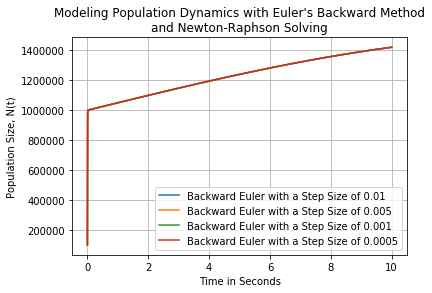

In [21]:
# Section 5: Results & Analysis

# Solution comparison (different step sizes with Euler's Backward)
solutions = {}

plt.figure()

for h in backward_step_sizes: # Uses multiple step sizes to analyze performance
    t, N, iterations, converged = euler_backward(h)
    solutions[h] = {"t": t, "N": N, "iterations": iterations, "converged": converged}
    
    plt.plot(solutions[h]["t"], solutions[h]["N"], label=f"Backward Euler with a Step Size of {h}")
    
# Plotting
plt.title("Modeling Population Dynamics with Euler's Backward Method\nand Newton-Raphson Solving")
plt.xlabel("Time in Seconds")
plt.ylabel("Population Size, N(t)")
plt.legend()
plt.grid()
plt.show()

## Section 5: Results & Analysis
### Part A: Step Size Comparison
From the plot of Euler's Backward Method, it is clear that the tested step sizes are all stable, suggesting that the maximum stable step size for this method is even larger than 0.01. This is distinctly greater than Euler's Forward Method, which had a maximum stable step size less than 0.005.

### Part B: Accuracy vs. Computational Cost
Although this will be discussed in greater detail in the next section, it is important to note that maintaining accuracy while using a larger step size (and thus fewer steps) is key to reducing computational costs. This indicates that, for this model, Euler's Backward Method reduces computational burden to a greater degree than Euler's Forward Method.

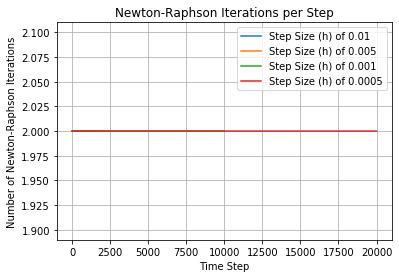

In [22]:
# Newton-Raphson iterations per time step

plt.figure()

for h in backward_step_sizes:
    time_steps = np.arange(1, len(solutions[h]["iterations"])+1)
    plt.plot(time_steps, solutions[h]["iterations"], label=f"Step Size (h) of {h}")
    
plt.title("Newton-Raphson Iterations per Step")
plt.xlabel("Time Step")
plt.ylabel("Number of Newton-Raphson Iterations")
plt.legend()
plt.grid()
plt.show()

### Part C: Convergence Behavior
The plot of Newton-Raphson iterations per step shows a constant iteration count of two for all step sizes. This indicates uniform convergence, despite step size variations, because the residual equation is linear in $N$. However, it's important to note that larger step sizes usually make nonlinear implicit equations harder to solve. Additionally, for nonlinear systems, a poor intitial guess can have drastic effects on the number of Newton-Raphson iterations, potentially resulting in convergence failure.

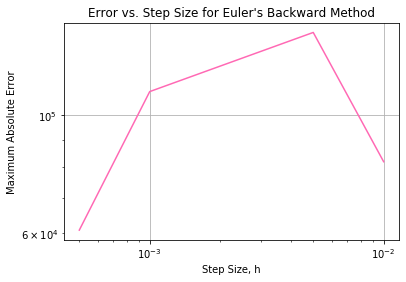

In [23]:
# Part D: Solution Quality

# Error vs. Step Size Plot

reference_h = 0.00005
reference_t, reference_N, reference_iterations, reference_converges = euler_backward(reference_h)

errors = []
small_steps = []

for h in backward_step_sizes:
    t = solutions[h]["t"]
    N = solutions[h]["N"]
    reference_N_but_better = np.interp(t, reference_t, reference_N)

    error = np.max(np.abs(N - reference_N_but_better))
    small_steps.append(h)
    errors.append(error)

small_steps = np.array(small_steps)
errors = np.array(errors)

sorting = np.argsort(small_steps)
small_steps = small_steps[sorting]
errors = errors[sorting]

plt.figure()
plt.loglog(small_steps, errors, color="hotpink")
plt.title("Error vs. Step Size for Euler's Backward Method")
plt.xlabel("Step Size, h")
plt.ylabel("Maximum Absolute Error")
plt.grid()
plt.show()

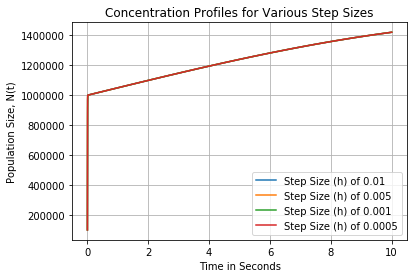

In [24]:
# Concentration Profile

plt.figure()

for h in backward_step_sizes:
    plt.plot(solutions[h]["t"], solutions[h]["N"], label=f"Step Size (h) of {h}")
    
plt.title("Concentration Profiles for Various Step Sizes")
plt.xlabel("Time in Seconds")
plt.ylabel("Population Size, N(t)")
plt.legend()
plt.grid()
plt.show()

### Part D: Solution Quality
The concentration profiles only reiterate the data presented in the solution comparison plot. However, the Error vs. Step Size plot presents a previously unseen pattern by showing how error generally increases as step size increases. Furthermore, these plots verify that the solution remains in physical bounds by maintaining a population greater than zero. Additionally, after the initial transient, the fast transient is resolved, and the model's slow dynamics actually match expected behavior.

## Section 6: Performance Analysis
#### (Similar to in Part 1, I wasn't sure how to insert a table into a markdown cell, but I go into a fair amount of detail in this paragraph to make up for it! Euler's Forward and Euler's Backward are compared at length.)
To reiterate what I touched on in Section 5, Part B, maintaining accuracy while using a larger step size (and thus fewer steps) is key to reducing computational costs. This indicates that, for this model, Euler's Backward Method reduces computational burden to a greater degree than Euler's Forward Method by being stable at larger step sizes. Although Euler's Forward Method is a more simple method, it generates computational costs by requiring an impractically small step size for stability. In other scenarios or with other models, there may be a greater need to discuss trade-offs between accuracy and efficiency, but, in modeling these specific dynamics, I would recommend Euler's Backward Method for its clearly superior accuracy at a similar, if not higher, level of efficiency.

## Section 7: Conclusions
My key finding in this part of the project was how to implement Euler's Backward Method as a way to solve stiff ordinary differential equations. Doing so emphasized the importance of implicit methods since an explicit method would not be suitable or stable enough to represent my chosen model. However, implementing Euler's Backward Method was not without its challenges; particularly, I struggled with debugging my Newton-Raphson solver (and formatting the many equations in this part's markdown cells).